In [1]:
import os
from glob import glob

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random
from tqdm import tqdm
import cv2
from PIL import Image
from torch.utils.data import Subset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, 
    precision_score, recall_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

import torch
from torch import optim, nn
import torch.nn.functional as F 
from torchvision import transforms as T, models
from torch.utils.data import Dataset, DataLoader, random_split
from torch.amp import autocast, GradScaler  

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# CUDA optimizations
torch.backends.cudnn.benchmark = True  # Auto-tune for faster convolutions
torch.backends.cudnn.deterministic = False  # Allow non-deterministic for speed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PATH = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'

Using device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB


### Load data

In [2]:
all_image_paths = {
    os.path.basename(p): p for p in glob(f'{PATH}/images_*/images/*.png')
}
print('Images found:', len(all_image_paths))

labels = pd.read_csv(f'{PATH}/Data_Entry_2017.csv')
labels.rename(columns={'Follow-up #' : 'follow_up', 'OriginalImage[Width': 'OriginalImageWidth', 'Height]': 'OriginalImageHeight', 'OriginalImagePixelSpacing[x': 'OriginalImagePixelSpacing_x', 'y]': 'OriginalImagePixelSpacing_y'}, inplace=True)
labels.columns = [
    re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', col).capitalize().replace(' ', '_')
    for col in labels.columns
]
labels = labels[['Image_index', 'Finding_labels', 'Follow_up', 'Patient_id', 'Patient_age', 'Patient_gender', 'View_position']]

labels.loc[labels['Patient_age'] > 100, 'Patient_age'] = np.nan #Min: 148, Max: 414 yrs old
labels['Patient_age'] = labels.groupby('Patient_id')['Patient_age'].ffill().bfill()

label_cols = labels['Finding_labels'].str.get_dummies(sep='|')
labels = pd.concat([labels, label_cols], axis=1)
labels['Finding_labels'] = np.where(labels['Finding_labels'] == 'No Finding', 0, 1)
# labels.drop(columns=['Finding_labels'], inplace=True)
labels.rename(columns={'No Finding': 'No_Finding'}, inplace=True)
labels.sort_values(by=['Patient_id', 'Follow_up'], inplace=True)
labels.head()

Images found: 112120


,Image_index,Finding_labels,Follow_up,Patient_id,Patient_age,Patient_gender,View_position,Atelectasis,Cardiomegaly,Consolidation,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No_Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,1,0,1,58.0,M,PA,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,1,1,1,58.0,M,PA,0,1,0,...,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,1,2,1,58.0,M,PA,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,0,0,2,81.0,M,PA,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,00000003_000.png,1,0,3,81.0,F,PA,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [3]:
# Random split
# patient_ids = labels['Patient_id'].unique()
# np.random.shuffle(patient_ids)

# n_train = int(len(patient_ids) * 0.8)
# train_patients = patient_ids[: n_train]
# test_patients = patient_ids[n_train :]

# train_labels = labels[labels['Patient_id'].isin(train_patients)].reset_index(drop=True)
# test_labels = labels[labels['Patient_id'].isin(test_patients)].reset_index(drop=True)

with open(f'{PATH}/train_val_list.txt', 'r') as file:
    train_list = file.read().split('\n')

with open(f'{PATH}/test_list.txt', 'r') as file:
    test_list = file.read().split('\n')

train_labels = labels.loc[labels['Image_index'].isin(train_list)].copy()
test_labels = labels.loc[labels['Image_index'].isin(test_list)].copy()

print(f'Train shape: {train_labels.shape}')
print(f'Test shape: {test_labels.shape}')
assert set(train_labels['Patient_id']).isdisjoint(test_labels['Patient_id'])

Train shape: (86524, 22)
Test shape: (25596, 22)


In [4]:
# Basic dataset information
print('=== Basic Dataset Information ===')
print(f'Total number of images: {len(labels)}')
print(f'Total number of unique patients: {labels['Patient_id'].nunique()}')
print(f'Dataset shape: {labels.shape}')

print('\n=== Train Set Information ===')
print(f'Number of images (train): {len(train_labels)}')
print(f'Number of unique patients (train): {train_labels['Patient_id'].nunique()}')
print(f'Train set shape: {train_labels.shape}')

print('\n=== Test Set Information ===')
print(f'Number of images (test): {len(test_labels)}')
print(f'Number of unique patients (test): {test_labels['Patient_id'].nunique()}')
print(f'Test set shape: {test_labels.shape}')

=== Basic Dataset Information ===
Total number of images: 112120
Total number of unique patients: 30805
Dataset shape: (112120, 22)

=== Train Set Information ===
Number of images (train): 86524
Number of unique patients (train): 28008
Train set shape: (86524, 22)

=== Test Set Information ===
Number of images (test): 25596
Number of unique patients (test): 2797
Test set shape: (25596, 22)


In [5]:
disease_cols = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
    'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass',
    'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
]

# Class distributions
disease_counts_train = train_labels[disease_cols].sum().sort_values(ascending=False)
disease_counts_include_nf_train = train_labels[disease_cols + ['No_Finding']].sum().sort_values(ascending=False)
disease_counts_test = test_labels[disease_cols].sum().sort_values(ascending=False)
disease_counts_include_nf_test = test_labels[disease_cols + ['No_Finding']].sum().sort_values(ascending=False)

# Percentage of disease labels on train data
disease_pct = (disease_counts_include_nf_train / len(train_labels) * 100).round(2)
print(f'\nDisease prevalence (%):\n{disease_pct}')

# Percentage of disease labels on test data
disease_pct = (disease_counts_include_nf_test / len(test_labels) * 100).round(2)
print(f'\nDisease prevalence (%):\n{disease_pct}')


Disease prevalence (%):
No_Finding            58.37
Infiltration          15.93
Effusion              10.01
Atelectasis            9.57
Nodule                 5.44
Mass                   4.66
Consolidation          3.30
Pneumothorax           3.05
Pleural_Thickening     2.59
Cardiomegaly           1.97
Emphysema              1.64
Edema                  1.59
Fibrosis               1.45
Pneumonia              1.01
Hernia                 0.16
dtype: float64

Disease prevalence (%):
No_Finding            38.53
Infiltration          23.88
Effusion              18.20
Atelectasis           12.81
Pneumothorax          10.41
Consolidation          7.09
Mass                   6.83
Nodule                 6.34
Pleural_Thickening     4.47
Emphysema              4.27
Cardiomegaly           4.18
Edema                  3.61
Pneumonia              2.17
Fibrosis               1.70
Hernia                 0.34
dtype: float64


In [6]:
# def create_balanced_subset(df, disease_cols, samples_per_class=100, min_total=2000):
#     selected_indices = set()
    
#     for col in disease_cols:
#         positive_indices = df[df[col] == 1].index.tolist()
#         n_select = min(samples_per_class, len(positive_indices))
#         selected_indices.update(np.random.choice(positive_indices, n_select, replace=False))
    
#     remaining_indices = list(set(df.index) - selected_indices)
#     n_remaining = max(0, min_total - len(selected_indices))
#     if n_remaining > 0 and len(remaining_indices) > 0:
#         additional = np.random.choice(remaining_indices, min(n_remaining, len(remaining_indices)), replace=False)
#         selected_indices.update(additional)
    
#     subset_df = df.loc[list(selected_indices)].reset_index(drop=True)
#     return subset_df

# # Train test subset
# train_labels_subset = create_balanced_subset(train_labels, disease_cols, samples_per_class=150, min_total=3000)
# test_labels_subset = create_balanced_subset(test_labels, disease_cols, samples_per_class=50, min_total=800)

# print('=== Train Subset ===')
# print(f'Total samples: {len(train_labels_subset)}')
# print('Samples per class:')
# print(train_labels_subset[disease_cols].sum().to_string())

# print('\n=== Test Subset ===')
# print(f'Total samples: {len(test_labels_subset)}')
# print('Samples per class:')
# print(test_labels_subset[disease_cols].sum().to_string())

# train_labels = train_labels_subset
# test_labels = test_labels_subset

### Preprocessing

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, data, image_paths, label_cols, transform=None):
        self.data = data.reset_index(drop=True)
        self.image_paths = image_paths   
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        img_name = self.data.iloc[index]['Image_index']
        img_path = self.image_paths.get(img_name)

        if img_path is None:
            raise FileNotFoundError(f'Image not found: {img_name}')

        img = Image.open(img_path).convert('RGB')
        label = self.data.iloc[index][self.label_cols].values.astype(np.float32)

        if self.transform:
            img = self.transform(img)

        return img, label


train_transform = T.Compose([
    T.Resize((256, 256)), 
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# train_transform = T.Compose([
#     T.Resize((256, 256)), 
#     T.RandomResizedCrop(224, scale=(0.8, 1.0)),  
#     T.RandomRotation(15),
#     T.ColorJitter(brightness=0.2, contrast=0.2), 
#     T.ToTensor(),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     T.RandomErasing(p=0.1, scale=(0.02, 0.1))  
# ])

# test_transform = T.Compose([
#     T.Resize((256, 256)),
#     T.CenterCrop(224),
#     T.ToTensor(),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

train = ImageDataset(train_labels, image_paths=all_image_paths, label_cols=disease_cols, transform=train_transform)
test = ImageDataset(test_labels, image_paths=all_image_paths, label_cols=disease_cols, transform=test_transform)
print(f'Length of trainset: {len(train)}')
print(f'Length of testset: {len(test)}')
print(f'Number of classes: {len(disease_cols)}')

Length of trainset: 86524
Length of testset: 25596
Number of classes: 14


Text(0.5, 1.0, 'Cardiomegaly')

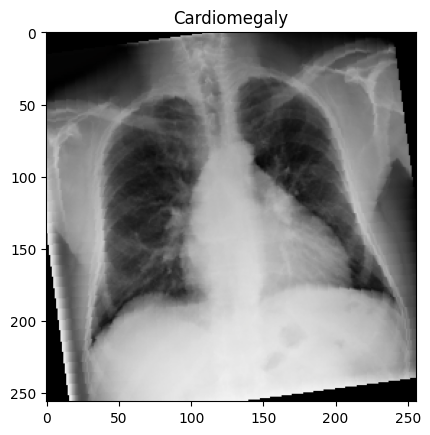

In [8]:
def deprocess(img):
    img = img.permute(1,2,0) #(C, H, W) -> (H, W, C) for ploting matplotlib
    img = img * torch.Tensor([0.229, 0.224, 0.225]) + torch.Tensor([0.485, 0.456, 0.406])
    return img

image, label = train[0]
class_labels = list(np.where(label==1)[0])
plt.imshow(deprocess(image))
plt.title(', '.join([disease_cols[i] for i in class_labels]))

In [ ]:
NUM_WORKERS = 4  
PIN_MEMORY = torch.cuda.is_available() 

def get_sample_weights(labels_df, disease_cols):
    """
    Calculate sample weights for WeightedRandomSampler
    Samples with rare diseases get higher weights
    """
    # Class frequencies (inverse)
    class_counts = labels_df[disease_cols].sum(axis=0).values
    total_samples = len(labels_df)
    class_weights = total_samples / (class_counts + 1e-6)
    
    # Normalize weights
    class_weights = class_weights / class_weights.sum() * len(disease_cols)
    
    # Sample weight = max weight of its positive labels (or 1 if no positive)
    sample_weights = []
    for idx in range(len(labels_df)):
        row_labels = labels_df.iloc[idx][disease_cols].values
        positive_indices = np.where(row_labels == 1)[0]
        
        if len(positive_indices) > 0:
            weight = max(class_weights[positive_indices])
        else:
            weight = 1.0
        sample_weights.append(weight)
    
    return torch.DoubleTensor(sample_weights)

sample_weights = get_sample_weights(train_labels, disease_cols)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
print(f'Sample weights - Min: {sample_weights.min():.4f}, Max: {sample_weights.max():.4f}, Mean: {sample_weights.mean():.4f}')

train_loader = DataLoader(train, batch_size=128, shuffle=False, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, 
                          persistent_workers=True if NUM_WORKERS > 0 else False)
test_loader = DataLoader(test, batch_size=128, shuffle=False, 
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, 
                         persistent_workers=True if NUM_WORKERS > 0 else False)

Sample weights - Min: 0.0782, Max: 7.6422, Mean: 0.7254


### Model

In [ ]:
class Net(nn.Module):
    def __init__(self, num_classes=14, dropout_rate=0.3):
        super(Net, self).__init__()
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        
        for name, param in self.backbone.named_parameters():
            if 'features.0' in name or 'features.1' in name or 'features.2' in name or \
               'features.3' in name or 'features.4' in name:
                param.requires_grad = False
        
        num_features = self.backbone.classifier[1].in_features
        
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(inplace=True), 
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_rate * 0.6),
            nn.Linear(256, num_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.backbone.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.backbone(x)

model = Net(num_classes=len(disease_cols), dropout_rate=0.3).to(device)
print(f'Model: EfficientNet-B0')
print(f'Model loaded on: {device}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 125MB/s] 


Model: EfficientNet-B0
Model loaded on: cuda
Total parameters: 4,799,882
Trainable parameters: 4,491,222


### Training

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, pos_weight=None, label_smoothing=0.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.label_smoothing = label_smoothing
        
    def forward(self, inputs, targets):
        # Label smoothing for noisy labels
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + self.label_smoothing / 2
        
        bce_loss = F.binary_cross_entropy_with_logits(
            inputs, targets, 
            pos_weight=self.pos_weight,
            reduction='none'
        )
        pt = torch.exp(-bce_loss) 
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        return focal_loss.mean()

def weighted_loss(pos_weights, neg_weights, y_pred, y_true, epsilon=1e-7):
    loss = 0.0
    for i in range(len(pos_weights)):
        loss_pos = -1 * torch.mean(pos_weights[i] * y_true[:,i] * torch.log(y_pred[:,i] + epsilon))
        loss_neg = -1 * torch.mean(neg_weights[i] * (1-y_true[:,i]) * torch.log((1-y_pred[:,i]) + epsilon))
        loss += loss_pos + loss_neg
    return loss

In [ ]:
# ==================== TRAINING CONFIGURATION ====================
epochs = 20 
n_folds = 3  
batch_size = 128  
learning_rate = 5e-4 
weight_decay = 1e-4 
label_smoothing = 0.1 

scaler = GradScaler('cuda') if torch.cuda.is_available() else None
use_amp = torch.cuda.is_available()

# Using WeightedRandomSampler instead for class balancing
freq = train_labels[disease_cols].sum(axis=0).values
total = len(train_labels)
# pos_weight = torch.tensor((total - freq) / (freq + 1e-6), dtype=torch.float32, device=device)
# print('Class weights (pos_weight):')
# for i, col in enumerate(disease_cols):
#     print(f'  {col}: {pos_weight[i].item():.2f}')
print('NOTE: pos_weight DISABLED - using Focal Loss + WeightedRandomSampler instead')
print(f'Class frequencies:')
for i, col in enumerate(disease_cols):
    print(f'  {col}: {freq[i]} ({freq[i]/total*100:.2f}%)')

groups = train_labels['Patient_id'].values
gkf = GroupKFold(n_splits=5)

RESUME_FOLD = 3  # Fold cần train
CHECKPOINT_PATH = f'/kaggle/input/datasets/zoey041/checkpoint/model_fold{RESUME_FOLD}.pt'

train_losses = []
val_losses = []
val_aucs = []
best_models = []

print(f'\n=== Training Configuration ===')
print(f'Epochs: {epochs}')
print(f'Folds: {n_folds}')
print(f'Batch size: {batch_size}')
print(f'Learning rate: {learning_rate}')
print(f'Weight decay: {weight_decay}')
print(f'Label smoothing: {label_smoothing}')
print(f'Loss: Focal Loss (alpha=1, gamma=2, NO pos_weight)\n')

# for fold, (train_idx, val_idx) in enumerate(gkf.split(train_labels, groups=groups)):
#     if fold >= n_folds:
#         break

#     if fold + 1 != RESUME_FOLD:
#         print(f'Skipping Fold {fold + 1} (already trained)')
#         continue
        
#     print(f'\n{'='*25} Fold {fold + 1}/{n_folds} {'='*25}')
    
#     train_subset = Subset(train, train_idx)
#     val_subset = Subset(train, val_idx)
    
#     # Create WeightedRandomSampler for train subset
#     subset_weights = sample_weights[train_idx]
#     fold_sampler = WeightedRandomSampler(
#         weights=subset_weights,
#         num_samples=len(subset_weights),
#         replacement=True
#     )
    
#     loader_train = DataLoader(train_subset, batch_size=batch_size, shuffle=False, 
#                               sampler=fold_sampler,
#                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, 
#                               persistent_workers=True if NUM_WORKERS > 0 else False)
#     loader_val = DataLoader(val_subset, batch_size=batch_size, shuffle=False, 
#                             num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
#                             persistent_workers=True if NUM_WORKERS > 0 else False)
    
#     print(f'Train size: {len(train_subset)}, Val size: {len(val_subset)}')
    
#     model = Net(num_classes=len(disease_cols), dropout_rate=0.3).to(device)
    
#     criterion = FocalLoss(alpha=1, gamma=2, pos_weight=None, label_smoothing=label_smoothing)
    
#     optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
#     iters_per_epoch = len(loader_train)
#     scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
#         optimizer, T_0=iters_per_epoch * 2, T_mult=2, eta_min=1e-6  
#     )
    
#     valid_loss_min = np.inf
#     best_val_auc = 0.0
#     fold_train_losses = []
#     fold_val_losses = []
#     fold_val_aucs = []
#     patience_counter = 0
#     early_stop_patience = 5  
#     start_epoch = 0 
    
#     global_step = 0

#     if os.path.exists(CHECKPOINT_PATH):
#         print(f'\n>>> Loading checkpoint from {CHECKPOINT_PATH}...')
        
#         checkpoint = torch.load(
#             CHECKPOINT_PATH,
#             map_location=device,
#             weights_only=False
#         )
    
#         model.load_state_dict(checkpoint['model_state_dict'])
#         optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
#         start_epoch = checkpoint['epoch'] + 1
#         best_val_auc = checkpoint['val_auc']
#         valid_loss_min = checkpoint['valid_loss']
    
#         print(f'>>> Resumed from epoch {start_epoch}, Best Val AUC: {best_val_auc:.2f}%')
#     else:
#         print(f'\n>>> No checkpoint found at {CHECKPOINT_PATH}. Training from scratch...\n')
    
#     for epoch in range(start_epoch, epochs):
#         current_lr = optimizer.param_groups[0]['lr']
        
#         # ========== Training ==========
#         model.train()
#         train_loss = 0.0
        
#         train_pbar = tqdm(loader_train, desc=f'Fold {fold+1} | Epoch {epoch+1}/{epochs} [Train]')
#         for batch_idx, (images, labels_batch) in enumerate(train_pbar):
#             images = images.to(device, non_blocking=True)
#             labels_batch = labels_batch.float().to(device, non_blocking=True)
            
#             optimizer.zero_grad(set_to_none=True)
            
#             if use_amp:
#                 with autocast('cuda'):
#                     outputs = model(images)
#                     loss = criterion(outputs, labels_batch)
                
#                 scaler.scale(loss).backward()
#                 scaler.unscale_(optimizer)
#                 torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                 scaler.step(optimizer)
#                 scaler.update()
#             else:
#                 outputs = model(images)
#                 loss = criterion(outputs, labels_batch)
#                 loss.backward()
#                 torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                 optimizer.step()
            
#             scheduler.step(epoch + batch_idx / iters_per_epoch)
#             current_lr = optimizer.param_groups[0]['lr']
            
#             train_loss += loss.item()
#             train_pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})
#             global_step += 1
        
#         avg_train_loss = train_loss / len(loader_train)
#         fold_train_losses.append(avg_train_loss)
        
#         # ========== Validation ==========
#         model.eval()
#         valid_loss = 0.0
#         all_preds = []
#         all_labels = []
        
#         with torch.no_grad():
#             val_pbar = tqdm(loader_val, desc=f'Fold {fold+1} | Epoch {epoch+1}/{epochs} [Val]')
#             for images, labels_batch in val_pbar:
#                 images = images.to(device, non_blocking=True)
#                 labels_batch = labels_batch.float().to(device, non_blocking=True)
                
#                 if use_amp:
#                     with autocast('cuda'):
#                         outputs = model(images)
#                         loss = criterion(outputs, labels_batch)
#                 else:
#                     outputs = model(images)
#                     loss = criterion(outputs, labels_batch)
                
#                 valid_loss += loss.item()
                
#                 preds = torch.sigmoid(outputs)
#                 all_preds.append(preds.cpu())
#                 all_labels.append(labels_batch.cpu())
                
#                 val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
#         avg_valid_loss = valid_loss / len(loader_val)
#         fold_val_losses.append(avg_valid_loss)
        
#         all_preds = torch.cat(all_preds).numpy()
#         all_labels = torch.cat(all_labels).numpy()
#         val_acc = ((all_preds >= 0.5) == all_labels).mean() * 100
        
#         try:
#             val_auc = roc_auc_score(all_labels, all_preds, average='macro') * 100
#         except:
#             val_auc = 0.0
#         fold_val_aucs.append(val_auc)
        
#         if val_auc > best_val_auc:
#             print(f'=> Val AUC improved ({best_val_auc:.2f}% -> {val_auc:.2f}%). Saving model...')
#             torch.save({
#                 'fold': fold,
#                 'epoch': epoch,
#                 'model_state_dict': model.state_dict(),
#                 'optimizer_state_dict': optimizer.state_dict(),
#                 'valid_loss': avg_valid_loss,
#                 'val_auc': val_auc,
#                 'val_accuracy': val_acc
#             }, f'model_fold{fold+1}.pt')
#             best_val_auc = val_auc
#             valid_loss_min = avg_valid_loss
#             patience_counter = 0
#         else:
#             patience_counter += 1
        
#         print(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.6f} | Val Loss = {avg_valid_loss:.6f} | Val Acc = {val_acc:.2f}% | Val AUC = {val_auc:.2f}% | LR = {current_lr:.2e}')
        
#         if patience_counter >= early_stop_patience:
#             print(f'Early stopping at epoch {epoch+1} (no improvement for {early_stop_patience} epochs)')
#             break
    
#     train_losses.append(fold_train_losses)
#     val_losses.append(fold_val_losses)
#     val_aucs.append(fold_val_aucs)
#     best_models.append(f'model_fold{fold+1}.pt')

print('\n>>> Loading and comparing all 3 models...\n')
model_files = [
    '/kaggle/input/datasets/zoey041/checkpoint/model_fold1.pt',
    '/kaggle/input/datasets/zoey041/checkpoint/model_fold2.pt',
    '/kaggle/input/datasets/zoey041/checkpoint/model_fold3.pt'
]
model_results = []

for model_file in model_files:
    if os.path.exists(model_file):
        checkpoint = torch.load(model_file, map_location=device, weights_only=False)
        result = {
            'model': model_file,
            'epoch': checkpoint.get('epoch', 'N/A'),
            'val_loss': checkpoint.get('valid_loss', 'N/A'),
            'val_auc': checkpoint.get('val_auc', 'N/A'),
            'val_accuracy': checkpoint.get('val_accuracy', 'N/A')
        }
        model_results.append(result)
        print(f'{model_file}:')
        print(f'  - Best Epoch: {result["epoch"]}')
        print(f'  - Val Loss: {result["val_loss"]:.6f}' if isinstance(result["val_loss"], float) else f'  - Val Loss: {result["val_loss"]}')
        print(f'  - Val AUC: {result["val_auc"]:.2f}%' if isinstance(result["val_auc"], float) else f'  - Val AUC: {result["val_auc"]}')
        print(f'  - Val Accuracy: {result["val_accuracy"]:.2f}%' if isinstance(result["val_accuracy"], float) else f'  - Val Accuracy: {result["val_accuracy"]}')
        print()
    else:
        print(f'{model_file}: NOT FOUND!')
        print()

if model_results:
    best_model = max(model_results, key=lambda x: x['val_auc'] if isinstance(x['val_auc'], float) else 0)
    print('='*60)
    print(f'BEST MODEL: {best_model["model"]}')
    print(f'  Val AUC: {best_model["val_auc"]:.2f}%' if isinstance(best_model["val_auc"], float) else f'  Val AUC: {best_model["val_auc"]}')
    print('='*60)
    
    aucs = [r['val_auc'] for r in model_results if isinstance(r['val_auc'], float)]
    if aucs:
        mean_auc = sum(aucs) / len(aucs)
        print(f'\nMean Val AUC across {len(aucs)} folds: {mean_auc:.2f}%')

print('\nAll models saved: model_fold1.pt, model_fold2.pt, model_fold3.pt')

Class frequencies:
  Atelectasis: 8280 (9.57%)
  Cardiomegaly: 1707 (1.97%)
  Consolidation: 2852 (3.30%)
  Edema: 1378 (1.59%)
  Effusion: 8659 (10.01%)
  Emphysema: 1423 (1.64%)
  Fibrosis: 1251 (1.45%)
  Hernia: 141 (0.16%)
  Infiltration: 13782 (15.93%)
  Mass: 4034 (4.66%)
  Nodule: 4708 (5.44%)
  Pleural_Thickening: 2242 (2.59%)
  Pneumonia: 876 (1.01%)
  Pneumothorax: 2637 (3.05%)

=== Training Configuration ===
Epochs: 20
Folds: 3
Batch size: 128
Learning rate: 0.0005
Weight decay: 0.0001
Label smoothing: 0.1
Loss: Focal Loss (alpha=1, gamma=2, NO pos_weight)


>>> Loading and comparing all 3 models...

/kaggle/input/datasets/zoey041/checkpoint/model_fold1.pt:
  - Best Epoch: 16
  - Val Loss: 0.051594
  - Val AUC: 79.85%
  - Val Accuracy: 95.57%

/kaggle/input/datasets/zoey041/checkpoint/model_fold2.pt:
  - Best Epoch: 18
  - Val Loss: 0.061721
  - Val AUC: 79.51%
  - Val Accuracy: 95.56%

/kaggle/input/datasets/zoey041/checkpoint/model_fold3.pt:
  - Best Epoch: 13
  - Val Loss

In [12]:
# fig, axes = plt.subplots(2, len(train_losses), figsize=(6*len(train_losses), 8))
# if len(train_losses) == 1:
#     axes = axes.reshape(2, 1)

# for i, (train_loss, val_loss, val_auc) in enumerate(zip(train_losses, val_losses, val_aucs)):
#     # Loss curve
#     axes[0, i].plot(range(1, len(train_loss)+1), train_loss, 'b-', label='Train Loss', linewidth=2)
#     axes[0, i].plot(range(1, len(val_loss)+1), val_loss, 'r-', label='Val Loss', linewidth=2)
#     axes[0, i].set_xlabel('Epoch')
#     axes[0, i].set_ylabel('Loss')
#     axes[0, i].set_title(f'Fold {i+1} - Loss Curve')
#     axes[0, i].legend()
#     axes[0, i].grid(True, alpha=0.3)
    
#     # AUC curve
#     axes[1, i].plot(range(1, len(val_auc)+1), val_auc, 'g-', label='Val AUC-ROC', linewidth=2, marker='o')
#     axes[1, i].set_xlabel('Epoch')
#     axes[1, i].set_ylabel('AUC-ROC (%)')
#     axes[1, i].set_title(f'Fold {i+1} - Validation AUC-ROC')
#     axes[1, i].legend()
#     axes[1, i].grid(True, alpha=0.3)
    
#     # Mark best epoch
#     best_epoch = np.argmax(val_auc) + 1
#     best_auc = max(val_auc)
#     axes[1, i].axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_auc:.2f}%')
#     axes[1, i].scatter([best_epoch], [best_auc], color='red', s=100, zorder=5)

# plt.suptitle('Training Progress - EfficientNet-B0 Baseline', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

# print(f'Best validation AUC across folds: {max([max(auc) for auc in val_aucs]):.2f}%')

In [ ]:
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    precision_score, recall_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

def find_optimal_thresholds(all_labels, all_preds, disease_cols, min_precision=0.15):
    optimal_thresholds = {}
    threshold_results = []

    for i, col in enumerate(disease_cols):
        y_true = all_labels[:, i]
        y_pred = all_preds[:, i]

        best_f1 = 0
        best_threshold = 0.5
        best_metrics = {}

        for thresh in np.arange(0.1, 0.61, 0.02):
            pred_binary = (y_pred >= thresh).astype(int)

            # Calculate metrics
            precision = precision_score(y_true, pred_binary, zero_division=0)
            recall = recall_score(y_true, pred_binary, zero_division=0)
            f1 = f1_score(y_true, pred_binary, zero_division=0)

            if precision >= min_precision and f1 > best_f1:
                best_f1 = f1
                best_threshold = thresh
                best_metrics = {
                    'precision': precision,
                    'recall': recall,
                    'f1': f1
                }

        optimal_thresholds[col] = best_threshold
        threshold_results.append({
            'Disease': col,
            'Optimal_Threshold': round(best_threshold, 2),
            'F1': round(best_metrics.get('f1', 0) * 100, 2),
            'Precision': round(best_metrics.get('precision', 0) * 100, 2),
            'Recall': round(best_metrics.get('recall', 0) * 100, 2)
        })

    df_thresholds = pd.DataFrame(threshold_results)
    return optimal_thresholds, df_thresholds


def evaluate_model(dataloader, model, disease_cols, threshold=0.5, thresholds_dict=None, dataset_name='Dataset'):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f'Evaluating {dataset_name}'):
            images = images.to(device, non_blocking=True)

            if use_amp:
                with autocast('cuda'):
                    outputs = model(images)
            else:
                outputs = model(images)

            preds = torch.sigmoid(outputs)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    # Per-class comprehensive metrics
    results = []
    for i, col in enumerate(disease_cols):
        if thresholds_dict is not None:
            thresh = thresholds_dict.get(col, threshold)
        else:
            thresh = threshold

        pred_binary = (all_preds[:, i] >= thresh).astype(int)
        true_labels = all_labels[:, i].astype(int)

        tp = ((pred_binary == 1) & (true_labels == 1)).sum()
        tn = ((pred_binary == 0) & (true_labels == 0)).sum()
        fp = ((pred_binary == 1) & (true_labels == 0)).sum()
        fn = ((pred_binary == 0) & (true_labels == 1)).sum()

        accuracy = (pred_binary == true_labels).mean() * 100

        try:
            auc = roc_auc_score(true_labels, all_preds[:, i]) * 100
        except:
            auc = 0.0

        precision = precision_score(true_labels, pred_binary, zero_division=0) * 100
        recall = recall_score(true_labels, pred_binary, zero_division=0) * 100
        f1 = f1_score(true_labels, pred_binary, zero_division=0) * 100

        results.append({
            'Disease': col,
            'Threshold': round(thresh, 2),
            'Accuracy': round(accuracy, 2),
            'AUC-ROC': round(auc, 2),
            'Precision': round(precision, 2),
            'Recall': round(recall, 2),
            'F1-Score': round(f1, 2),
            'TP': int(tp),
            'TN': int(tn),
            'FP': int(fp),
            'FN': int(fn),
            'Total_Positive': int(true_labels.sum()),
            'Predicted_Positive': int(pred_binary.sum())
        })

    df_results = pd.DataFrame(results)

    # Overall metrics
    print(f'\n{'='*60}')
    print(f'{dataset_name.upper()} EVALUATION RESULTS')
    print(f'{'='*60}')
    print(f'Threshold mode: {"Per-class optimal" if thresholds_dict else f"Fixed ({threshold})"}')
    print(f'Mean AUC-ROC: {df_results["AUC-ROC"].mean():.2f}%')
    print(f'Mean F1-Score: {df_results["F1-Score"].mean():.2f}%')
    print(f'Mean Precision: {df_results["Precision"].mean():.2f}%')
    print(f'Mean Recall: {df_results["Recall"].mean():.2f}%')
    print(f'{'='*60}\n')

    return df_results, all_preds, all_labels


def plot_threshold_analysis(all_labels, all_preds, disease_cols):
    fig, axes = plt.subplots(4, 4, figsize=(18, 16))
    axes = axes.flatten()

    for i, col in enumerate(disease_cols):
        ax = axes[i]
        y_true = all_labels[:, i]
        y_pred = all_preds[:, i]

        thresholds = np.arange(0.1, 0.7, 0.02)
        f1_scores = []
        precisions = []
        recalls = []

        for thresh in thresholds:
            pred_binary = (y_pred >= thresh).astype(int)
            f1_scores.append(f1_score(y_true, pred_binary, zero_division=0))
            precisions.append(precision_score(y_true, pred_binary, zero_division=0))
            recalls.append(recall_score(y_true, pred_binary, zero_division=0))

        ax.plot(thresholds, f1_scores, 'b-', label='F1', linewidth=2)
        ax.plot(thresholds, precisions, 'g--', label='Precision', linewidth=1.5)
        ax.plot(thresholds, recalls, 'r--', label='Recall', linewidth=1.5)

        best_idx = np.argmax(f1_scores)
        ax.axvline(thresholds[best_idx], color='blue', linestyle=':', alpha=0.7)
        ax.scatter([thresholds[best_idx]], [f1_scores[best_idx]], color='blue', s=50, zorder=5)

        ax.set_xlabel('Threshold')
        ax.set_ylabel('Score')
        ax.set_title(f'{col}', fontweight='bold')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0.1, 0.7])
        ax.set_ylim([0, 1])

    for j in range(len(disease_cols), len(axes)):
        axes[j].axis('off')

    plt.suptitle('Threshold Analysis: F1, Precision, Recall per Class', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_roc_curves(all_labels, all_preds, disease_cols, title_suffix=''):
    fig, axes = plt.subplots(4, 4, figsize=(16, 14))
    axes = axes.flatten()

    for i, col in enumerate(disease_cols):
        ax = axes[i]

        try:
            fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
            auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
            ax.plot(fpr, tpr, 'b-', label=f'AUC = {auc:.3f}')
            ax.plot([0, 1], [0, 1], 'r--', label='Random')
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title(f'{col}', fontweight='bold')
            ax.legend(loc='lower right')
            ax.grid(True, alpha=0.3)
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center')
            ax.set_title(f'{col}', fontweight='bold')

    for j in range(len(disease_cols), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'ROC Curves{title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def plot_precision_recall_curves(all_labels, all_preds, disease_cols, title_suffix=''):
    fig, axes = plt.subplots(4, 4, figsize=(16, 14))
    axes = axes.flatten()

    for i, col in enumerate(disease_cols):
        ax = axes[i]

        try:
            precision, recall, _ = precision_recall_curve(all_labels[:, i], all_preds[:, i])
            ap = average_precision_score(all_labels[:, i], all_preds[:, i])
            ax.plot(recall, precision, 'b-', label=f'AP = {ap:.3f}')
            ax.set_xlabel('Recall')
            ax.set_ylabel('Precision')
            ax.set_title(f'{col}', fontweight='bold')
            ax.legend(loc='lower left')
            ax.grid(True, alpha=0.3)
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
        except Exception as e:
            ax.text(0.5, 0.5, f'Error: {str(e)[:20]}', ha='center', va='center')
            ax.set_title(f'{col}', fontweight='bold')

    for j in range(len(disease_cols), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Precision-Recall Curves{title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def class_accuracy(dataloader, model, thresholds_dict=None, default_threshold=0.5):
    per_class_accuracy = [0 for i in range(len(disease_cols))]

    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if use_amp:
                with autocast('cuda'):
                    ps = model(images)
            else:
                ps = model(images)

            ps = torch.sigmoid(ps)

            for i in range(ps.shape[1]):
                thresh = thresholds_dict.get(disease_cols[i], default_threshold) if thresholds_dict else default_threshold
                pred_binary = (ps[:, i:i+1] >= thresh).float()
                per_class_accuracy[i] += int((pred_binary == labels[:, i:i+1]).sum())

        per_class_accuracy = [(i/len(dataloader.dataset))*100.0 for i in per_class_accuracy]

    return per_class_accuracy

def get_acc_data(class_names, acc_list):
    df = pd.DataFrame(list(zip(class_names, acc_list)), columns=['Labels', 'Acc'])
    return df

LOAD MODEL & FIND OPTIMAL THRESHOLDS
Loaded model from fold 1, epoch 17
Best validation loss: 0.051594
Best validation AUC: 79.85%

--- Getting predictions for threshold tuning ---


Getting train predictions: 100%|██████████| 676/676 [13:23<00:00,  1.19s/it]



--- Finding Optimal Thresholds (min precision: 15%) ---

Optimal Thresholds per Disease:


,Disease,Optimal_Threshold,F1,Precision,Recall
0,Atelectasis,0.36,33.33,36.76,30.49
1,Cardiomegaly,0.32,41.37,35.26,50.03
2,Consolidation,0.28,21.20,16.24,30.55
3,Edema,0.36,44.53,41.00,48.74
4,Effusion,0.36,41.60,38.07,45.85
5,Emphysema,0.36,47.15,46.54,47.77
6,Fibrosis,0.26,29.64,25.73,34.95
7,Hernia,0.44,91.25,98.33,85.11
8,Infiltration,0.36,34.96,30.51,40.93
9,Mass,0.36,35.85,36.27,35.45



Mean optimal threshold: 0.336

--- Threshold Analysis Plots ---


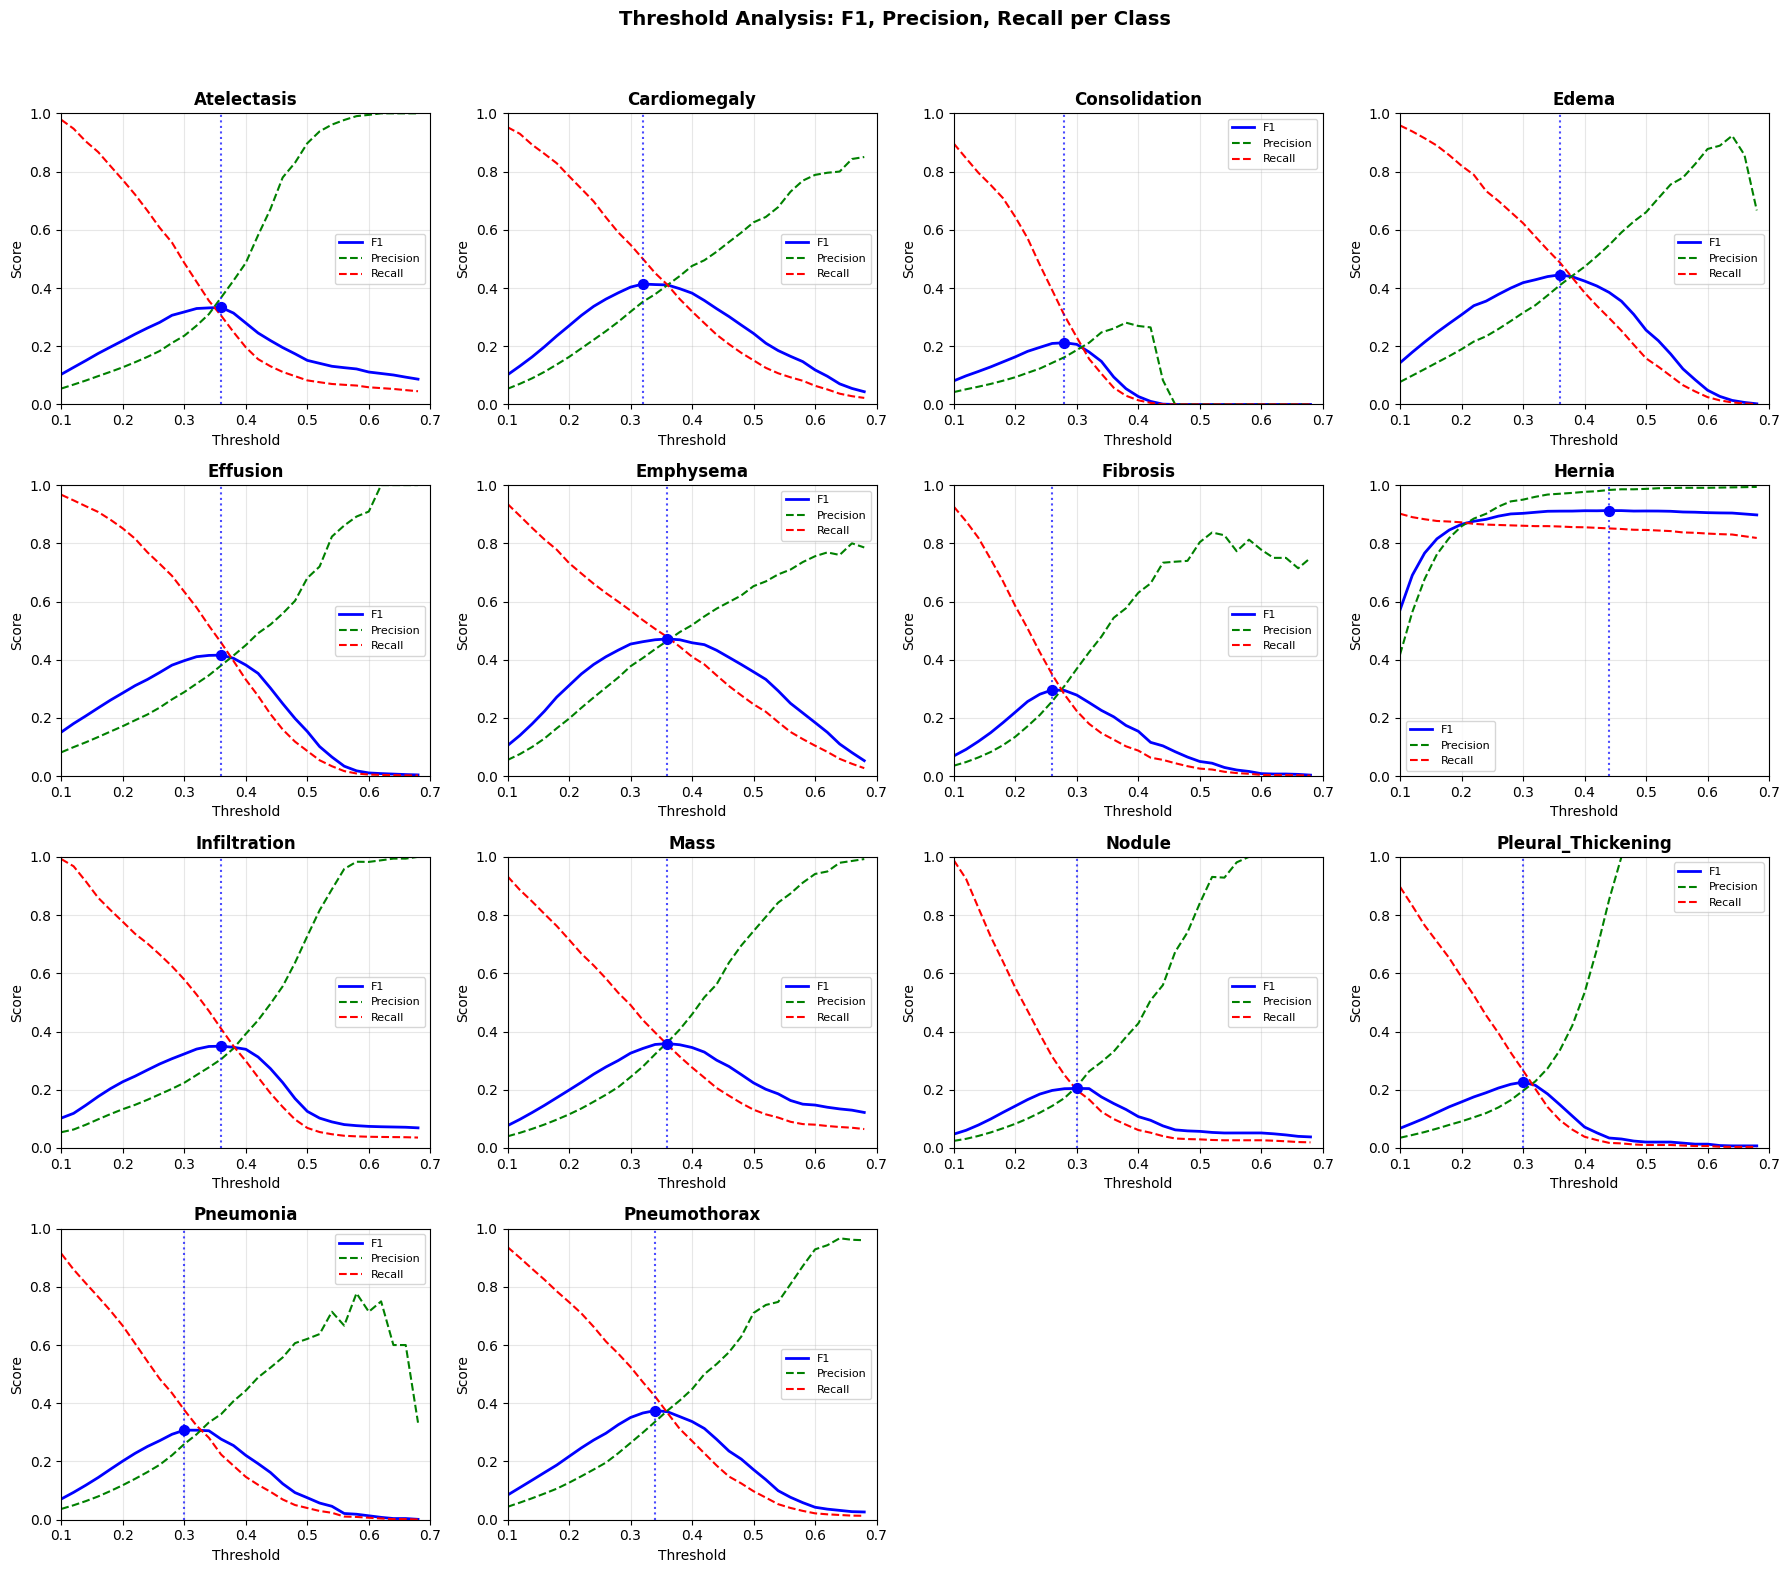

In [ ]:
# LOAD BEST MODEL & FIND OPTIMAL THRESHOLDS  
print('='*60)
print('LOAD MODEL & FIND OPTIMAL THRESHOLDS')
print('='*60)

checkpoint = torch.load('/kaggle/input/datasets/zoey041/checkpoint/model_fold1.pt', weights_only=False, map_location=device)
model = Net(num_classes=len(disease_cols), dropout_rate=0.3).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f'Loaded model from fold 1, epoch {checkpoint["epoch"]+1}')
print(f'Best validation loss: {checkpoint["valid_loss"]:.6f}')
print(f'Best validation AUC: {checkpoint["val_auc"]:.2f}%')

print('\n--- Getting predictions for threshold tuning ---')
model.eval()
all_train_preds = []
all_train_labels = []

with torch.no_grad():
    for images, labels_batch in tqdm(train_loader, desc='Getting train predictions'):
        images = images.to(device, non_blocking=True)
        if use_amp:
            with autocast('cuda'):
                outputs = model(images)
        else:
            outputs = model(images)
        preds = torch.sigmoid(outputs)
        all_train_preds.append(preds.cpu().numpy())
        all_train_labels.append(labels_batch.numpy())

all_train_preds = np.vstack(all_train_preds)
all_train_labels = np.vstack(all_train_labels)

print('\n--- Finding Optimal Thresholds (min precision: 15%) ---')
optimal_thresholds, threshold_df = find_optimal_thresholds(
    all_train_labels, all_train_preds, disease_cols, min_precision=0.15
)
print('\nOptimal Thresholds per Disease:')
display(threshold_df)

print(f'\nMean optimal threshold: {np.mean(list(optimal_thresholds.values())):.3f}')

print('\n--- Threshold Analysis Plots ---')
plot_threshold_analysis(all_train_labels, all_train_preds, disease_cols)

TEST DATASET COMPREHENSIVE EVALUATION

COMPARISON: Fixed Threshold (0.5) vs Optimal Thresholds

--- Method 1: Fixed Threshold (0.5) ---


Evaluating Test (Fixed 0.5): 100%|██████████| 200/200 [04:16<00:00,  1.28s/it]



TEST (FIXED 0.5) EVALUATION RESULTS
Threshold mode: Fixed (0.5)
Mean AUC-ROC: 76.39%
Mean F1-Score: 9.96%
Mean Precision: 41.68%
Mean Recall: 6.65%


--- Method 2: Optimal Per-Class Thresholds ---


Evaluating Test (Optimal): 100%|██████████| 200/200 [03:31<00:00,  1.06s/it]



TEST (OPTIMAL) EVALUATION RESULTS
Threshold mode: Per-class optimal
Mean AUC-ROC: 76.39%
Mean F1-Score: 28.57%
Mean Precision: 28.91%
Mean Recall: 31.76%


--- Comparison Summary ---


,Disease,Fixed_F1,Optimal_F1,Fixed_Precision,Optimal_Precision,Fixed_Recall,Optimal_Recall,Optimal_Threshold,F1_Improvement
0,Atelectasis,1.09,24.70,47.37,30.47,0.55,20.77,0.36,23.61
1,Cardiomegaly,21.30,35.14,55.29,33.97,13.19,36.39,0.32,13.84
2,Consolidation,0.00,20.76,0.00,15.29,0.00,32.34,0.28,20.76
3,Edema,12.24,22.84,20.35,15.77,8.76,41.41,0.36,10.60
4,Effusion,9.98,45.05,71.23,45.40,5.37,44.70,0.36,35.07
5,Emphysema,34.43,42.24,51.74,37.15,25.80,48.95,0.36,7.81
6,Fibrosis,1.32,14.16,15.79,10.10,0.69,23.68,0.26,12.84
7,Hernia,39.02,40.31,64.86,60.47,27.91,30.23,0.44,1.29
8,Infiltration,3.13,40.23,45.21,39.01,1.62,41.54,0.36,37.10
9,Mass,6.14,28.30,52.29,32.42,3.26,25.11,0.36,22.16



Mean F1 Improvement: 18.61%

--- Detailed Test Results (Optimal Thresholds) ---


,Disease,Threshold,Accuracy,AUC-ROC,Precision,Recall,F1-Score,TP,TN,FP,FN,Total_Positive,Predicted_Positive
0,Atelectasis,0.36,83.78,70.82,30.47,20.77,24.70,681,20763,1554,2598,3279,2235
1,Cardiomegaly,0.32,94.39,85.28,33.97,36.39,35.14,389,23771,756,680,1069,1145
2,Consolidation,0.28,82.50,71.74,15.29,32.34,20.76,587,20529,3252,1228,1815,3839
3,Edema,0.36,89.89,82.49,15.77,41.41,22.84,383,22625,2046,542,925,2429
4,Effusion,0.36,80.15,78.72,45.40,44.70,45.05,2082,18434,2504,2576,4658,4586
5,Emphysema,0.36,94.28,87.04,37.15,48.95,42.24,535,23598,905,558,1093,1440
6,Fibrosis,0.26,95.12,78.39,10.10,23.68,14.16,103,24244,917,332,435,1020
7,Hernia,0.44,99.70,82.05,60.47,30.23,40.31,26,25493,17,60,86,43
8,Infiltration,0.36,70.53,67.66,39.01,41.54,40.23,2539,15514,3970,3573,6112,6509
9,Mass,0.36,91.31,74.57,32.42,25.11,28.30,439,22933,915,1309,1748,1354



--- ROC Curves (Test Set) ---


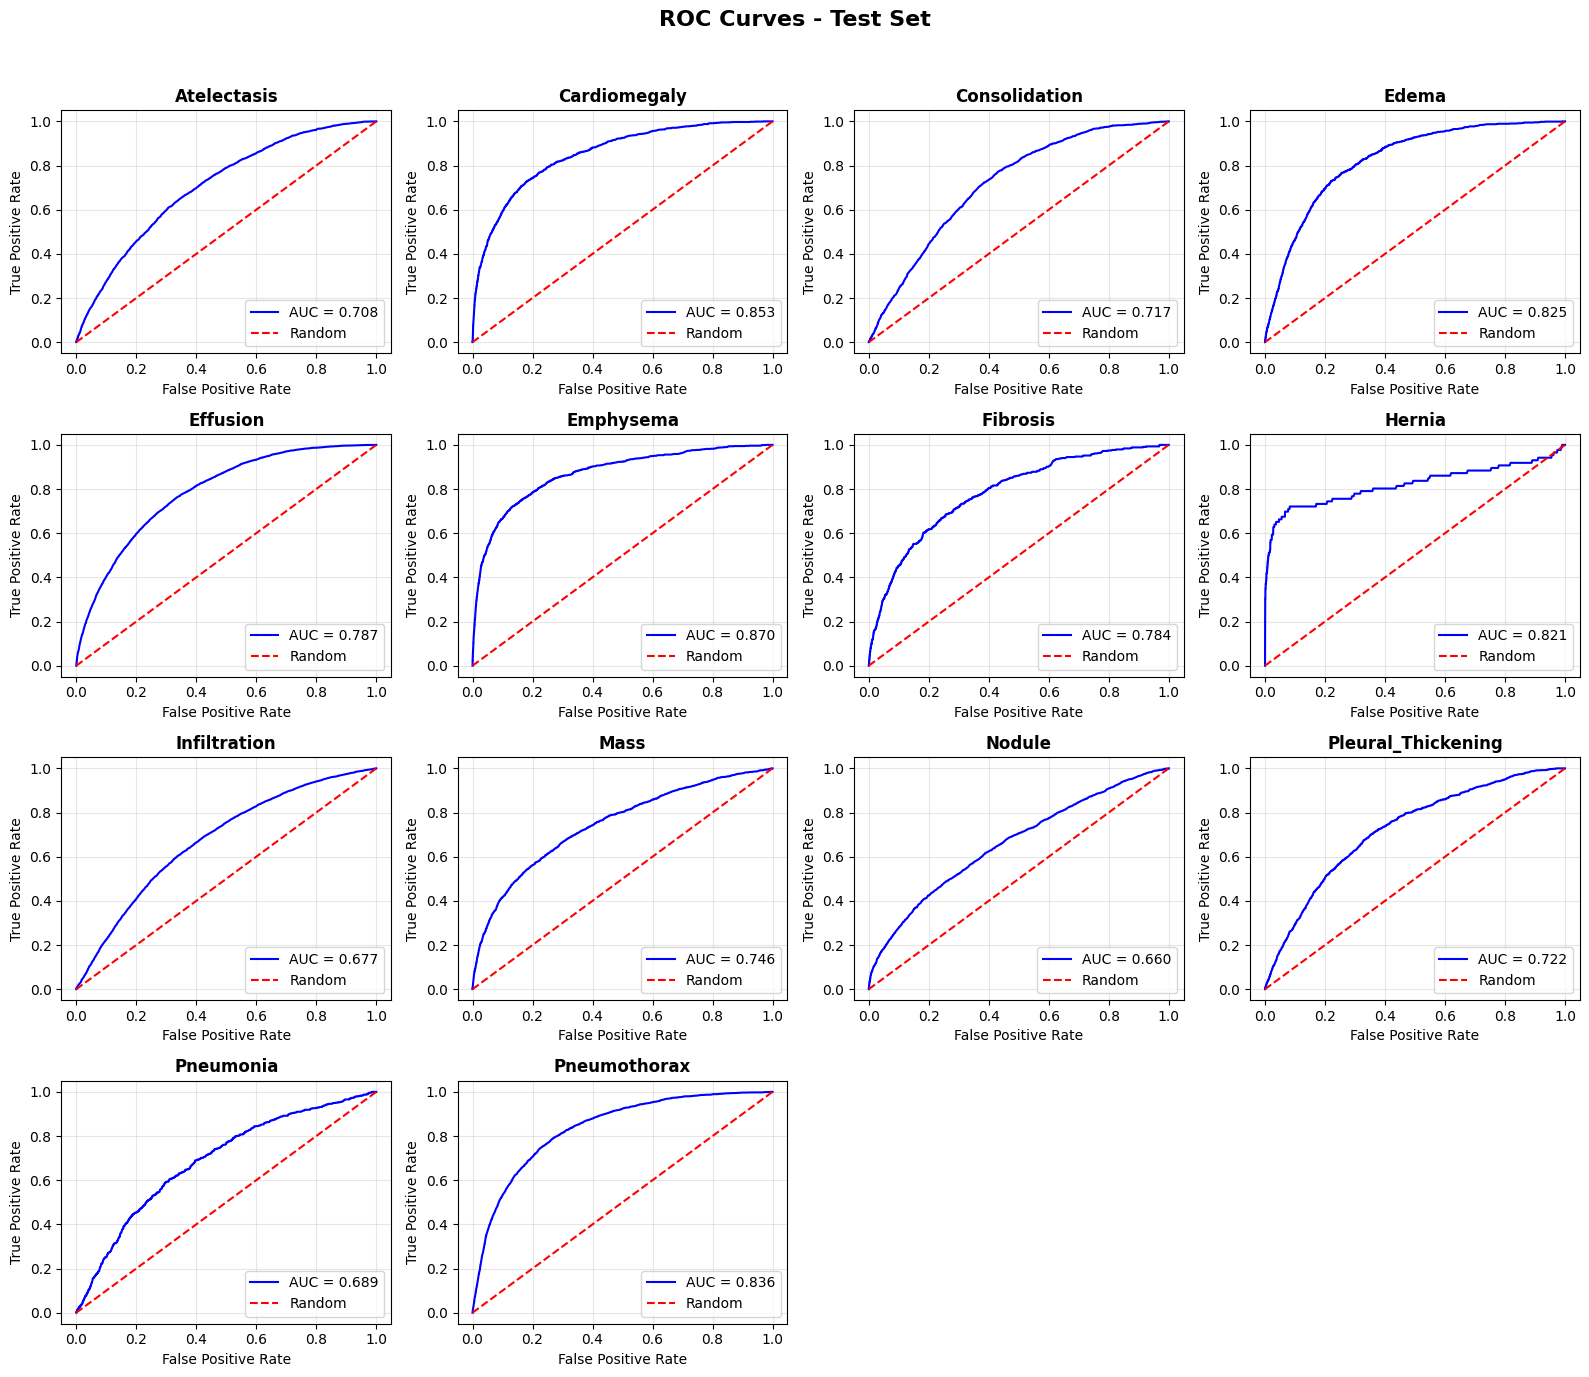


--- Precision-Recall Curves (Test Set) ---


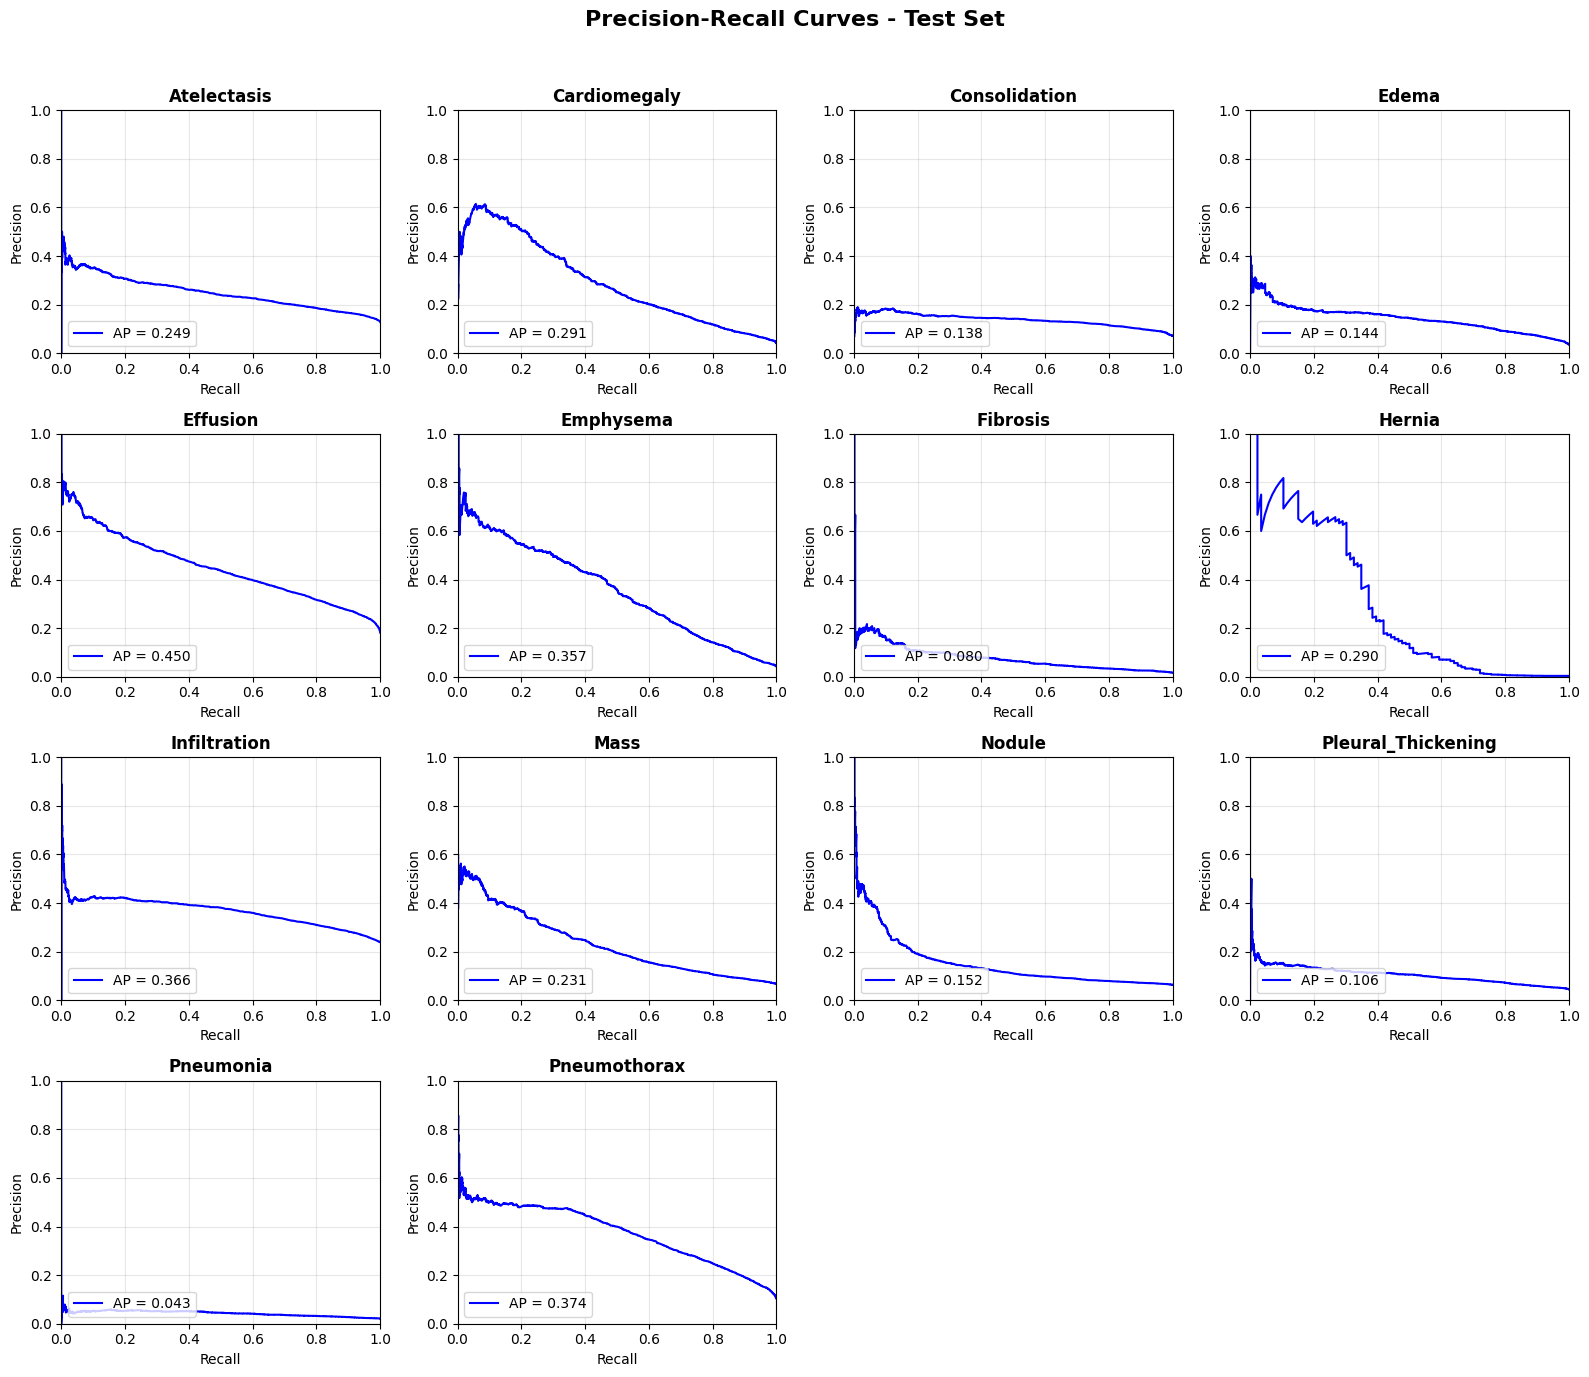


--- Class Accuracy (Test Set - Optimal Thresholds) ---


,Labels,Acc
0,Atelectasis,83.778715
1,Cardiomegaly,94.389748
2,Consolidation,82.497265
3,Edema,89.889045
4,Effusion,80.153149
5,Emphysema,94.284263
6,Fibrosis,95.120331
7,Hernia,99.699172
8,Infiltration,70.530552
9,Mass,91.311142



FINAL SUMMARY
Using Optimal Thresholds:
  Mean AUC-ROC: 76.39%
  Mean F1-Score: 28.57%
  Mean Precision: 28.91%
  Mean Recall: 31.76%

Using Fixed Threshold (0.5):
  Mean F1-Score: 9.96%
  Mean Precision: 41.68%
  Mean Recall: 6.65%


In [ ]:
# TEST DATASET COMPREHENSIVE EVALUATION
print('='*60)
print('TEST DATASET COMPREHENSIVE EVALUATION')
print('='*60)

print('\n' + '='*60)
print('COMPARISON: Fixed Threshold (0.5) vs Optimal Thresholds')
print('='*60)

# Method 1: Fixed threshold 0.5
print('\n--- Method 1: Fixed Threshold (0.5) ---')
test_results_fixed, test_preds, test_true = evaluate_model(
    test_loader, model, disease_cols, threshold=0.5, dataset_name='Test (Fixed 0.5)'
)

# Method 2: Optimal per-class thresholds
print('\n--- Method 2: Optimal Per-Class Thresholds ---')
test_results_optimal, _, _ = evaluate_model(
    test_loader, model, disease_cols, thresholds_dict=optimal_thresholds, dataset_name='Test (Optimal)'
)

# Side-by-side comparison
print('\n--- Comparison Summary ---')
comparison_df = pd.DataFrame({
    'Disease': disease_cols,
    'Fixed_F1': test_results_fixed['F1-Score'].values,
    'Optimal_F1': test_results_optimal['F1-Score'].values,
    'Fixed_Precision': test_results_fixed['Precision'].values,
    'Optimal_Precision': test_results_optimal['Precision'].values,
    'Fixed_Recall': test_results_fixed['Recall'].values,
    'Optimal_Recall': test_results_optimal['Recall'].values,
    'Optimal_Threshold': test_results_optimal['Threshold'].values
})
comparison_df['F1_Improvement'] = comparison_df['Optimal_F1'] - comparison_df['Fixed_F1']
display(comparison_df)

print(f'\nMean F1 Improvement: {comparison_df["F1_Improvement"].mean():.2f}%')

# Display detailed results with optimal thresholds
print('\n--- Detailed Test Results (Optimal Thresholds) ---')
display(test_results_optimal)

print('\n--- ROC Curves (Test Set) ---')
plot_roc_curves(test_true, test_preds, disease_cols, title_suffix=' - Test Set')

print('\n--- Precision-Recall Curves (Test Set) ---')
plot_precision_recall_curves(test_true, test_preds, disease_cols, title_suffix=' - Test Set')

print('\n--- Class Accuracy (Test Set - Optimal Thresholds) ---')
acc_list = class_accuracy(test_loader, model, thresholds_dict=optimal_thresholds)
acc_df = get_acc_data(disease_cols, acc_list)
display(acc_df)

# Summary comparison
print('\n' + '='*60)
print('FINAL SUMMARY')
print('='*60)
print(f'Using Optimal Thresholds:')
print(f'  Mean AUC-ROC: {test_results_optimal["AUC-ROC"].mean():.2f}%')
print(f'  Mean F1-Score: {test_results_optimal["F1-Score"].mean():.2f}%')
print(f'  Mean Precision: {test_results_optimal["Precision"].mean():.2f}%')
print(f'  Mean Recall: {test_results_optimal["Recall"].mean():.2f}%')
print(f'\nUsing Fixed Threshold (0.5):')
print(f'  Mean F1-Score: {test_results_fixed["F1-Score"].mean():.2f}%')
print(f'  Mean Precision: {test_results_fixed["Precision"].mean():.2f}%')
print(f'  Mean Recall: {test_results_fixed["Recall"].mean():.2f}%')
print('='*60)